In [ ]:
#ml r/4.2.2-py310-ly4mhww
#R RHOME
%env R_HOME=/opt/rit/el9/20230413/app/linux-rhel9-x86_64_v3/gcc-11.2.1/r-4.2.2-ly4mhww3hc75wzv4bygq2oisiochvsq4/rlib/R
#pandas.__version__

env: R_HOME=/opt/rit/el9/20230413/app/linux-rhel9-x86_64_v3/gcc-11.2.1/r-4.2.2-ly4mhww3hc75wzv4bygq2oisiochvsq4/rlib/R


In [2]:
import os
import numpy as np
import scanorama
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import pandas 
import pickle
from pandas import Index
# from pandas import PandasIndex
import anndata as ad
import scipy
import anndata2ri
anndata2ri.scipy2ri.activate()
import logging
import rpy2
from rpy2.robjects import pandas2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
#pandas.__version__
from plotnine import (
    ggplot, aes, geom_histogram, scale_x_continuous, facet_wrap, geom_vline,
    theme, element_text, labs, ylim
)

/tmp/ipykernel_1674156/1985819725.py:15: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.scipy2ri.activate()


In [3]:
adata_list = sc.read_h5ad("filtered_postQC_postcb_postdoublet_combined_adata_84dpi.h5ad")

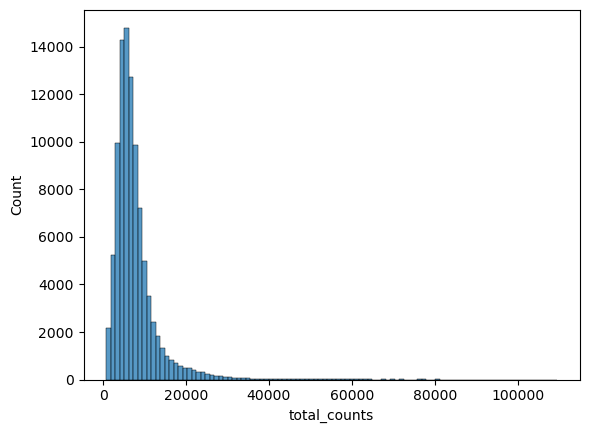

In [5]:
p1 = sns.histplot(adata_list.obs["total_counts"], bins=100, kde=False)

In [6]:
scales_counts = sc.pp.normalize_total(adata_list, target_sum=None, inplace=False)
# log1p transform
adata_list.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

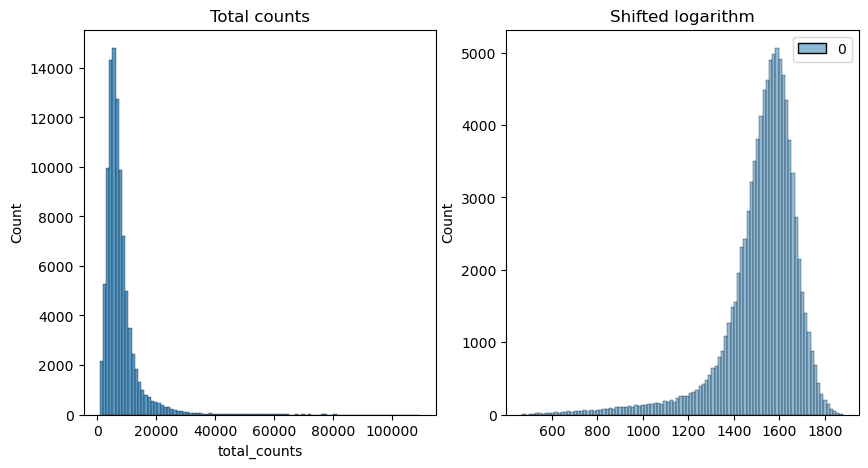

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata_list.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata_list.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [ ]:
sc.pp.scale(adata_list)
sc.pp.highly_variable_genes(adata_list, flavor='seurat_v3', layer="log1p_norm", n_top_genes=3000,n_bins =90)
adata_list.X = adata_list.layers["log1p_norm"]
adata_list.X = adata_list.layers["log1p_norm"]
sc.pp.pca(adata_list, n_comps=50, use_highly_variable=True, svd_solver='arpack')

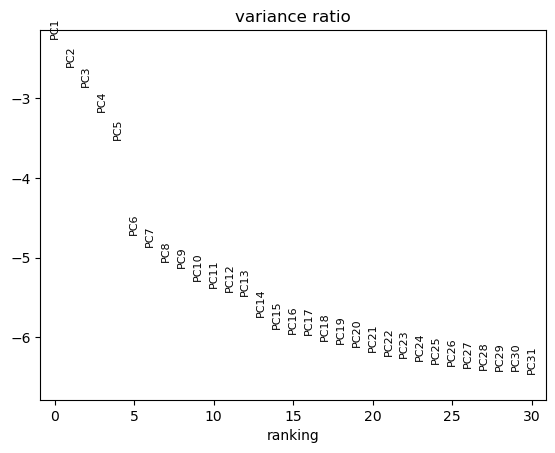

In [14]:
sc.pl.pca_variance_ratio(adata_list,n_pcs=30, log=True)

In [ ]:
sc.tl.tsne(adata_list, use_rep="X_pca")
sc.pp.neighbors(adata_list,n_pcs = 6, n_neighbors = 30)
sc.tl.umap(adata_list)


In [32]:
def split_umap(adata, split_by, ncol=2, nrow=None, **kwargs):
    categories = adata.obs[split_by].cat.categories
    if nrow is None:
        nrow = int(np.ceil(len(categories) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
    axs = axs.flatten()
    for i, cat in enumerate(categories):
        ax = axs[i]
        sc.pl.umap(adata[adata.obs[split_by] == cat], ax=ax, show=False, title=cat, **kwargs)
    plt.tight_layout()

In [ ]:
def split_umap_filter(adata, split_by, filter_by, filter_values, ncol=2, nrow=None, **kwargs):
    """
    Generate UMAP plots split by a specified categorical variable for specific filtered categories.
    """
    # Filter the data based on the  filter values
    filtered_adata = adata[adata.obs[filter_by].isin(filter_values)]
    
    categories = filtered_adata.obs[split_by].cat.categories
    if nrow is None:
        nrow = int(np.ceil(len(categories) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow))
    axs = axs.flatten()
    for i, cat in enumerate(categories):
        ax = axs[i]
        sc.pl.umap(filtered_adata[filtered_adata.obs[split_by] == cat], ax=ax, show=False, title=cat, **kwargs)
    plt.tight_layout()
    plt.show()

In [ ]:
sc.tl.louvain(adata_list)
sc.tl.louvain(adata_list, key_added="louvain_res0_25", resolution=0.25)
sc.tl.louvain(adata_list, key_added="louvain_res0_3", resolution=0.3)
sc.tl.louvain(adata_list, key_added="louvain_res0_4", resolution=0.4)
sc.tl.louvain(adata_list, key_added="louvain_res0_5", resolution=0.5)
sc.tl.louvain(adata_list, key_added="louvain_res0_8", resolution=0.8)
sc.tl.louvain(adata_list, key_added="louvain_res1", resolution=1.0)
sc.tl.louvain(adata_list, key_added="louvain_res1_2", resolution=1.2)
sc.tl.louvain(adata_list, key_added="louvain_res1_5", resolution=1.5)
sc.tl.louvain(adata_list, key_added="louvain_res2", resolution=2.0)


In [60]:
adata_list.layers["counts"] = adata_list.X

In [61]:
# markers = ('CD86', 'CD14', 'CD163', 'CSF1R', 'NLRP3', 'TLR4', 
#                                      'FLT3',  'FCER1A', 
#                                      'TCF4', 'XBP1', 'CLEC12A', 'CD93', 'IRF8',
#                                      'CD79A', 'CD19', 'PAX5', 'IRF4', 'PRDM1', 
#                                      'CD3E', 'CD2', 'TRDC', 'CD4', 'CD8B', 
#                                      'CD8A', 'CD5', 'CD6', 'PRF1', 'KLRK1', 'KLRB1', 'HCST', 'TYROBP', 
#                                      'HBM', 'AHSP')

# marker_genes_in_data2 = dict()
# for marker in markers:
#     if marker in adata_list.var.index:
#         marker_genes_in_data2[marker] = marker

# markers_found = list(marker_genes_in_data2.values())

# print(f'Markers found: {markers_found}')

/mnt/job-temp/mkapoor/5665716/ipykernel_93320/1867633826.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


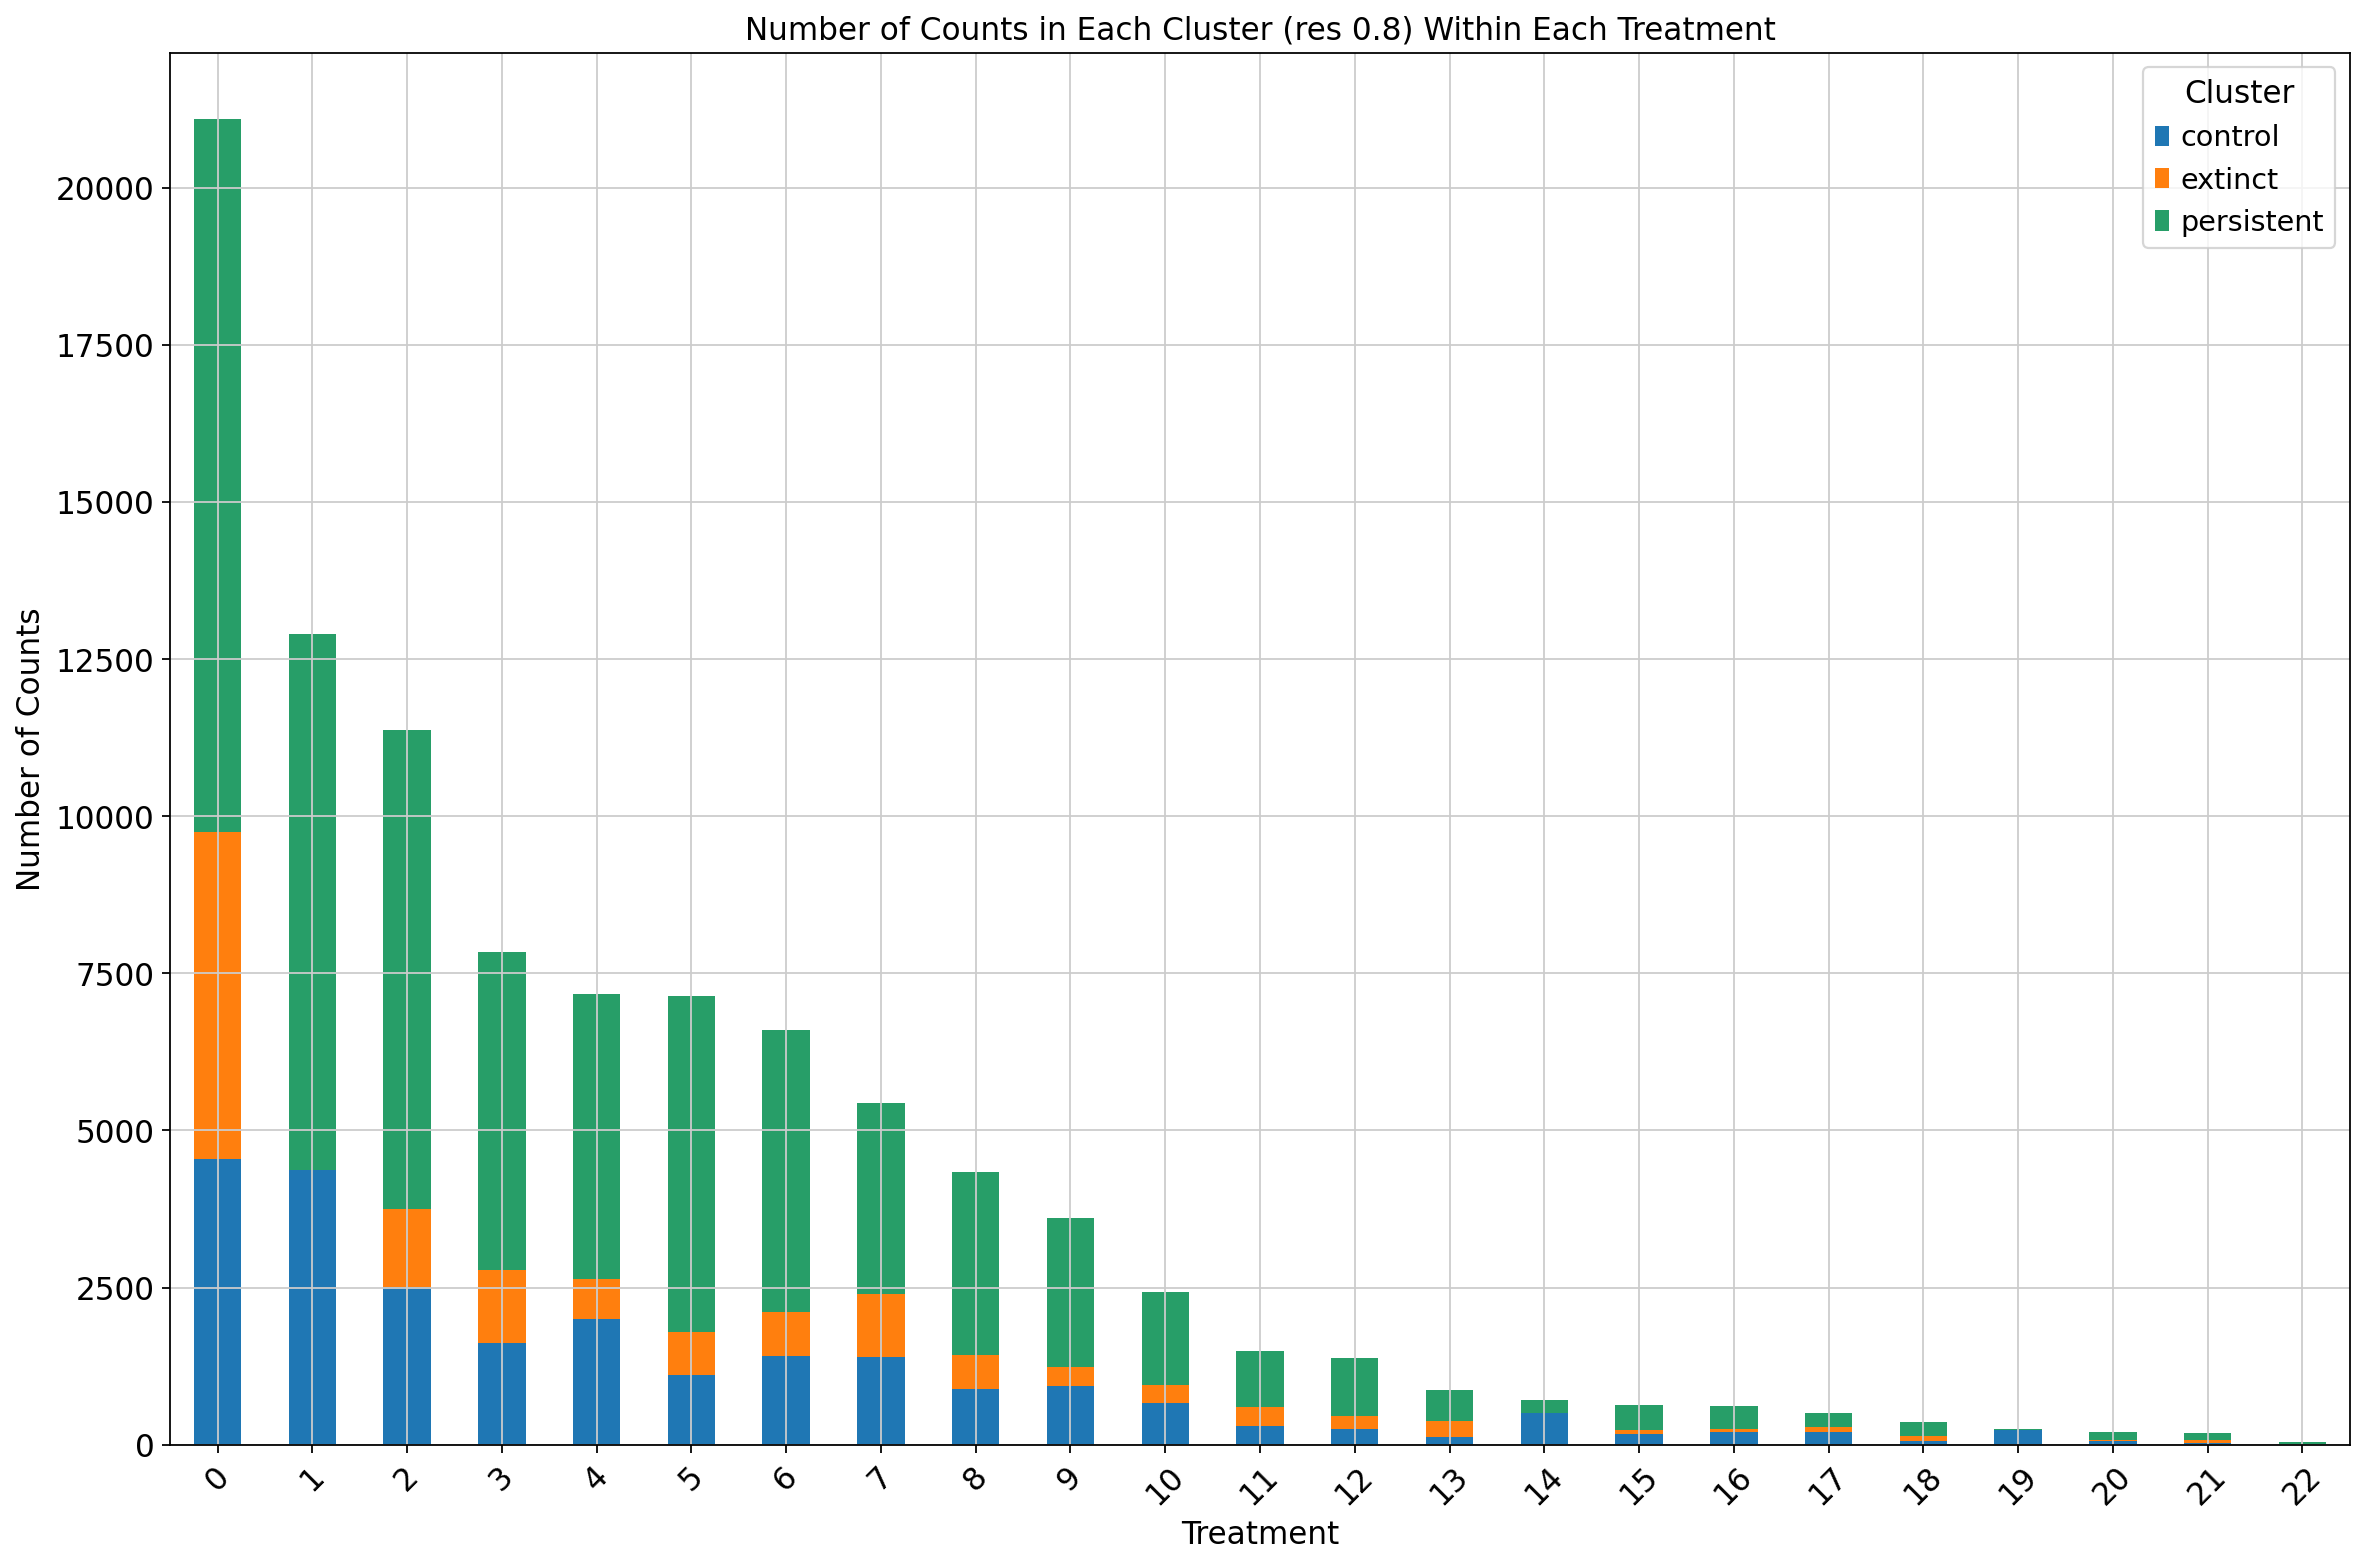

In [64]:
cluster_data = adata_list.obs[['Treatment', 'louvain_res0_8']]

# Count the number of occurrences of each cluster within each treatment
cluster_counts = cluster_data.groupby(['Treatment', 'louvain_res0_8']).size().reset_index(name='counts')

# Pivot the data for easier plotting
cluster_counts_pivot = cluster_counts.pivot(index='louvain_res0_8', columns='Treatment', values='counts').fillna(0)

# Plotting
plt.figure(figsize=(15, 10))
cluster_counts_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title('Number of Counts in Each Cluster (res 0.8) Within Each Treatment')
plt.xlabel('Treatment')
plt.ylabel('Number of Counts')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [68]:
clustering_info = adata_list.obs[['louvain_res0_25', 'louvain_res0_3', 'louvain_res0_4', 'louvain_res0_5', 'louvain_res0_8', 'louvain_res1', 'louvain_res1_2', 'louvain_res1_5', 'louvain_res2']]

In [ ]:
adata_list.write_h5ad('./PRRSV/filtered_postQC_postcb_postdoublet_postdowns_84dpi.h5ad')

In [ ]:
adata = sc.read_h5ad("./PRRSV/filtered_postQC_postcb_postdoublet_postdowns_postcellcycle_annotated_84dpi.h5ad")
adata

AnnData object with n_obs × n_vars = 97153 × 25880
    obs: 'Sample', 'Treatment', 'Sex', 'Sow', 'nFeaturess_RNA_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'louvain', 'louvain_res0_25', 'louvain_res0_3', 'louvain_res0_4', 'louvain_res0_5', 'louvain_res0_8', 'louvain_res1', 'louvain_res1_2', 'louvain_res1_5', 'louvain_res2', 'neworder', 'celltypes', 'nCount_RNA', 'nFeature_RNA', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'RNA_snn_res.0.25', 'seurat_clusters', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.2', 'CellTypes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

In [7]:
adata.obs['louvain_res0_8'] = adata.obs['louvain_res0_8'].astype(str)

In [8]:

new_levels = ['10','13','22',  # Monocytes
    '19',  # pDCs
    '6', '7',  # B cells
    '0','8','9','17','20',#AB T cells
    '21',  # Antibody-secreting cells
    '15',  # Transitional 
    '3','12','14',  # NK cells
    '11',  # CD2+ GD T cells
    '23' , # cdc
    '1', '2', '4', '5', '16','18'  # CD2- GD T cells
]

# Create new column in obs that reorders based on the levels
adata.obs['neworder'] = pd.Categorical(adata.obs['louvain_res0_8'], categories=new_levels, ordered=True)


                      neworder        celltypes
CTTCCTTAGGCATGCA-1-98       21              ASC
ACTTTCAAGTGTTCAC-1-98       20       AB T cells
TGACCCTAGAGGACTC-1-98       19             pDCs
TCATTCATCGTCCATC-1-98        6          B cells
ACGTAACGTATTGCCA-1-98       16  CD2- GD T cells
CCGCAAGTCAACACCA-1-98        0       AB T cells
ACCAACATCAAGTTGC-1-98        7          B cells
ATTTCACGTGTCCTAA-1-98       11  CD2+ GD T cells
GATGATCTCGCCAGAC-1-98       15   Transitional B
GGTAGAGGTTTCCATT-1-98        9       AB T cells
TCCTCTTCACGGCACT-1-98        3         NK cells
AGAAGTATCGCTCTCA-1-98        5  CD2- GD T cells
CTCACTGCATAGCTGT-1-98        8       AB T cells
CTTCCGACACTGTCGG-1-98        1  CD2- GD T cells
TCTATACGTTGCTTGA-1-98       12         NK cells
TCTCACGCAATTGCTG-1-98        2  CD2- GD T cells
CTCAACCCAGCTTTGA-1-98       17       AB T cells
TAGATCGGTAACGGTG-1-98        4  CD2- GD T cells
TCGTGGGGTCGTCTCT-1-98       14         NK cells
ACTACGAGTAGGTACG-1-98       18  CD2- GD 

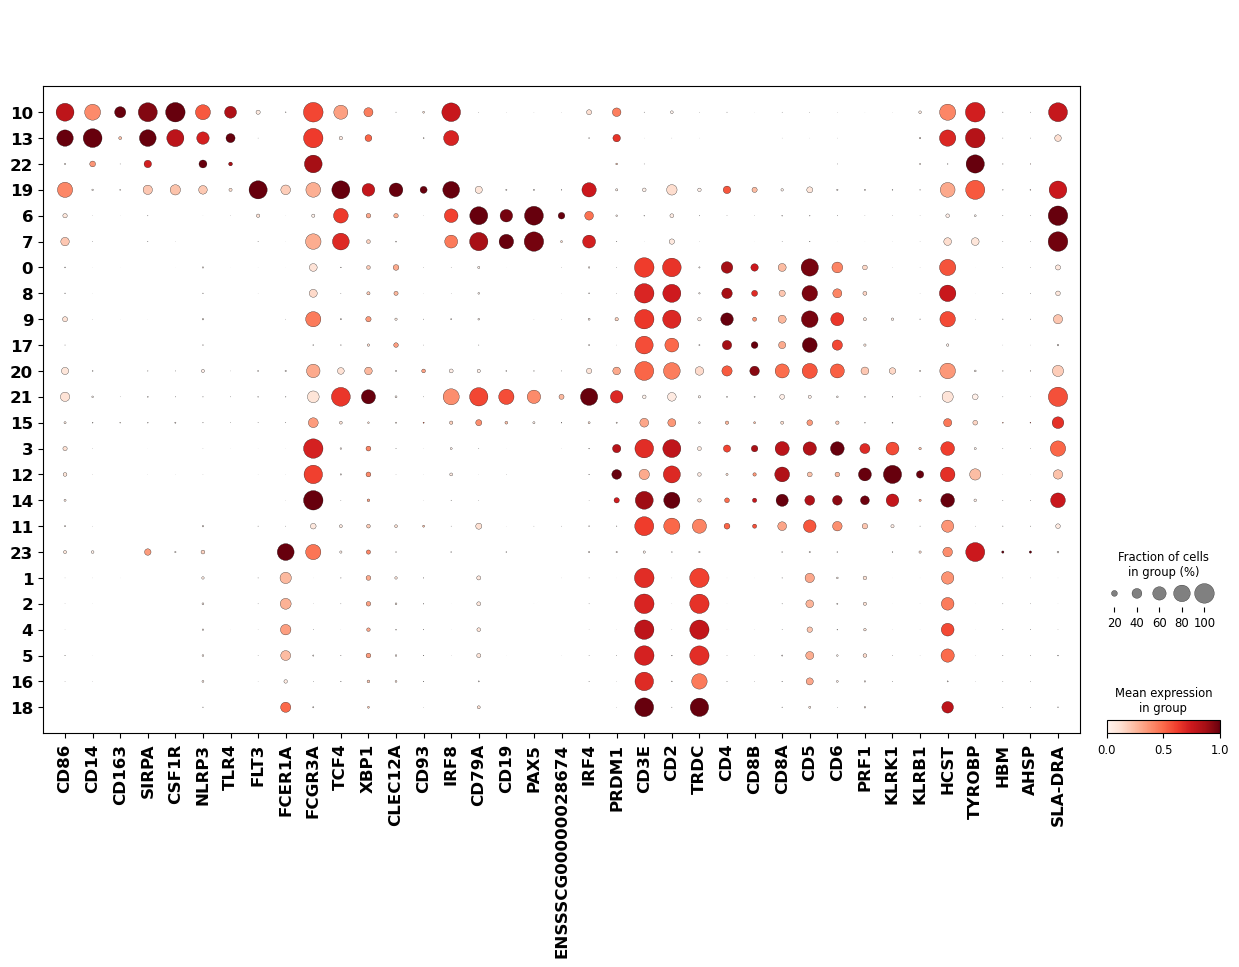

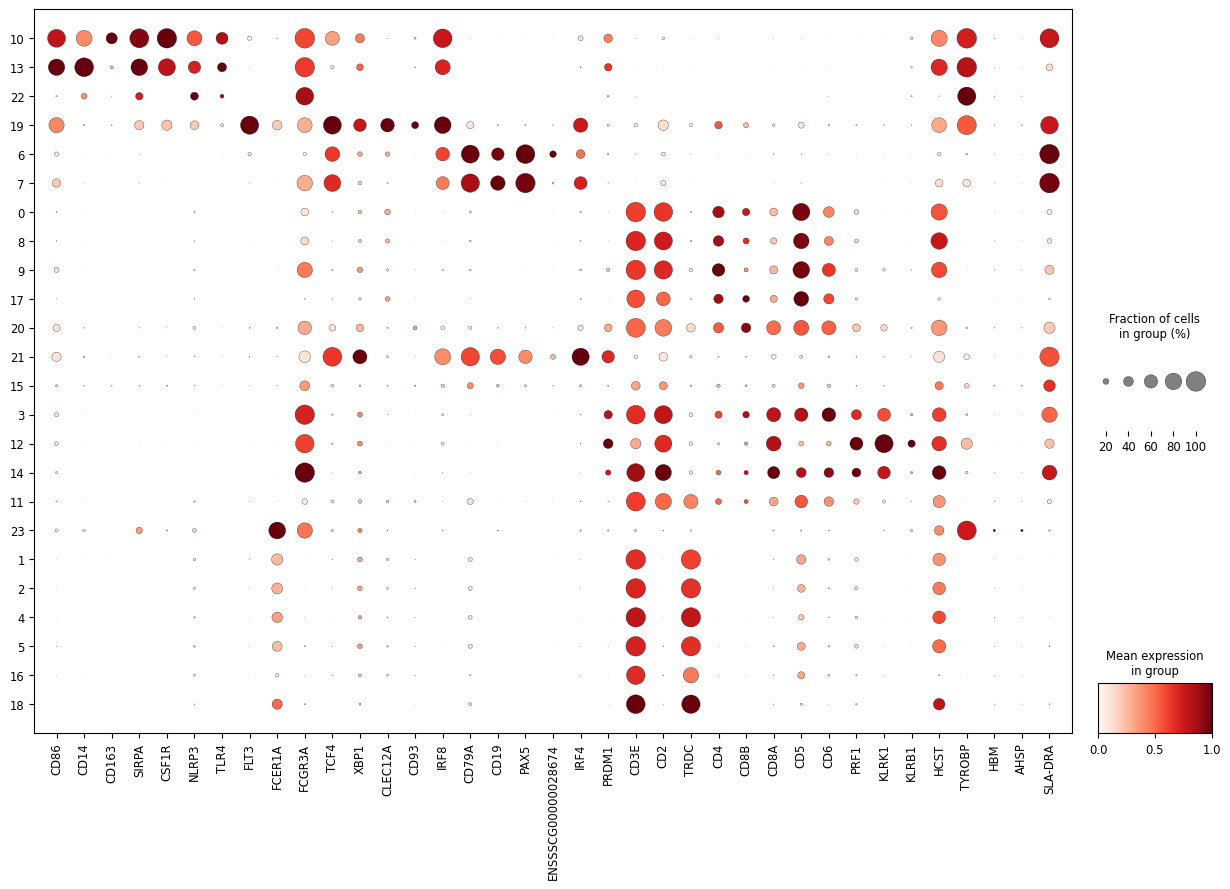

In [9]:
cell_types = ['Monocytes', 'Monocytes','Monocytes',  # 10,13,22
              'pDCs',                    # 19
              'B cells', 'B cells',  # 6,7
              'AB T cells', 'AB T cells', 'AB T cells', 'AB T cells', 'AB T cells', #0,8,9,17,20
              'ASC',                     # 21
              'Transitional B',  # 15
              'NK cells', 'NK cells', 'NK cells', # 3, 12, 14
              'CD2+ GD T cells',         # 11
              'cDCs', #23
              'CD2- GD T cells', 'CD2- GD T cells', 'CD2- GD T cells', 'CD2- GD T cells', 'CD2- GD T cells', 'CD2- GD T cells']  # 1, 2, 4, 5, 16, 18

# Assign the cell types to a new column
adata.obs['celltypes'] = adata.obs['neworder'].map(dict(zip(new_levels, cell_types)))

# Verify that the new cell type assignments are correct
print(adata.obs[['neworder', 'celltypes']].drop_duplicates())

# Now, generate the dot plot for the selected features
dp=sc.pl.dotplot(
    adata, 
    var_names=[ 'CD86', 'CD14', 'CD163', 'SIRPA','CSF1R', 'NLRP3', 'TLR4', 
                'FLT3', 'FCER1A', 'FCGR3A',
                'TCF4', 'XBP1', 'CLEC12A', 'CD93', 'IRF8',
                'CD79A', 'CD19', 'PAX5', 'ENSSSCG00000028674', 'IRF4', 'PRDM1', 
                'CD3E', 'CD2', 'TRDC', 'CD4', 'CD8B', 
                'CD8A', 'CD5', 'CD6', 'PRF1', 'KLRK1', 'KLRB1', 'HCST', 'TYROBP', 
                'HBM', 'AHSP', 'SLA-DRA'], 
    groupby='neworder', 
    standard_scale='var', 
    swap_axes=False,show=False, return_fig=True)
axes = dp.get_axes()
main_ax = axes['mainplot_ax']

for label in main_ax.get_xticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

for label in main_ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

#plt.setp(main_ax.get_xticklabels(), rotation=45, ha='right')

dp.show()

/scratch/mkapoor/6081351/ipykernel_1031825/2265483433.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


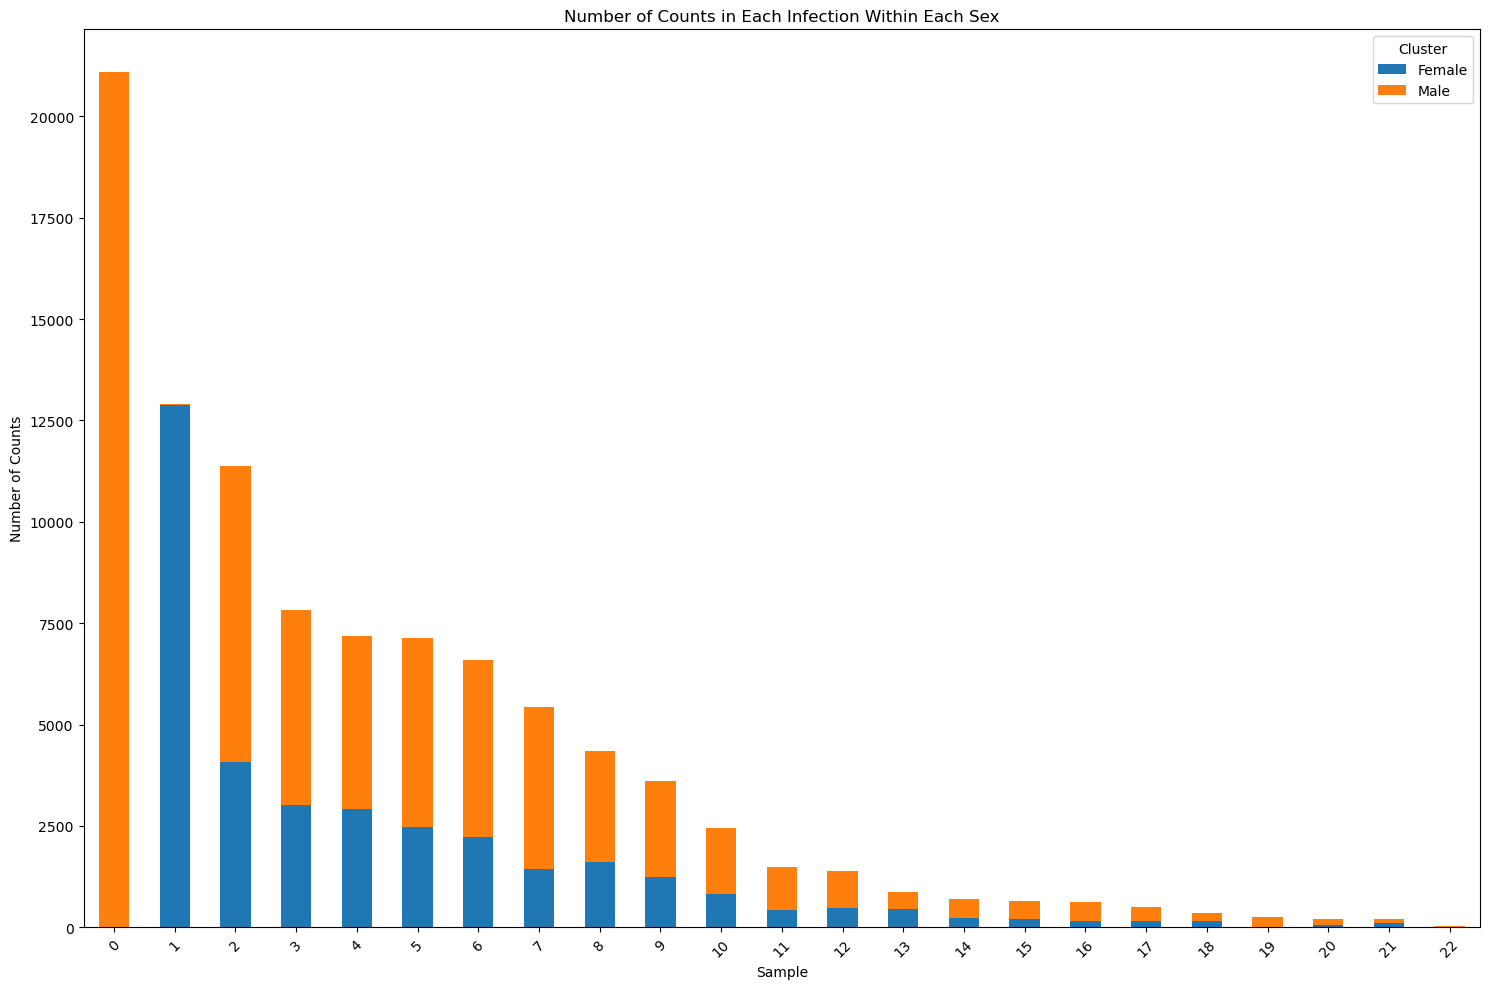

In [16]:
cluster_data = adata.obs[['Sex', 'louvain_res0_8']]

# Count the number of occurrences of each cluster within each treatment
cluster_counts = cluster_data.groupby(['Sex', 'louvain_res0_8']).size().reset_index(name='counts')

# Pivot the data for easier plotting
cluster_counts_pivot = cluster_counts.pivot(index='louvain_res0_8', columns='Sex', values='counts').fillna(0)

# Plotting
plt.figure(figsize=(15, 10))
cluster_counts_pivot.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title('Number of Counts in Each Infection Within Each Sex')
plt.xlabel('Sample')
plt.ylabel('Number of Counts')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

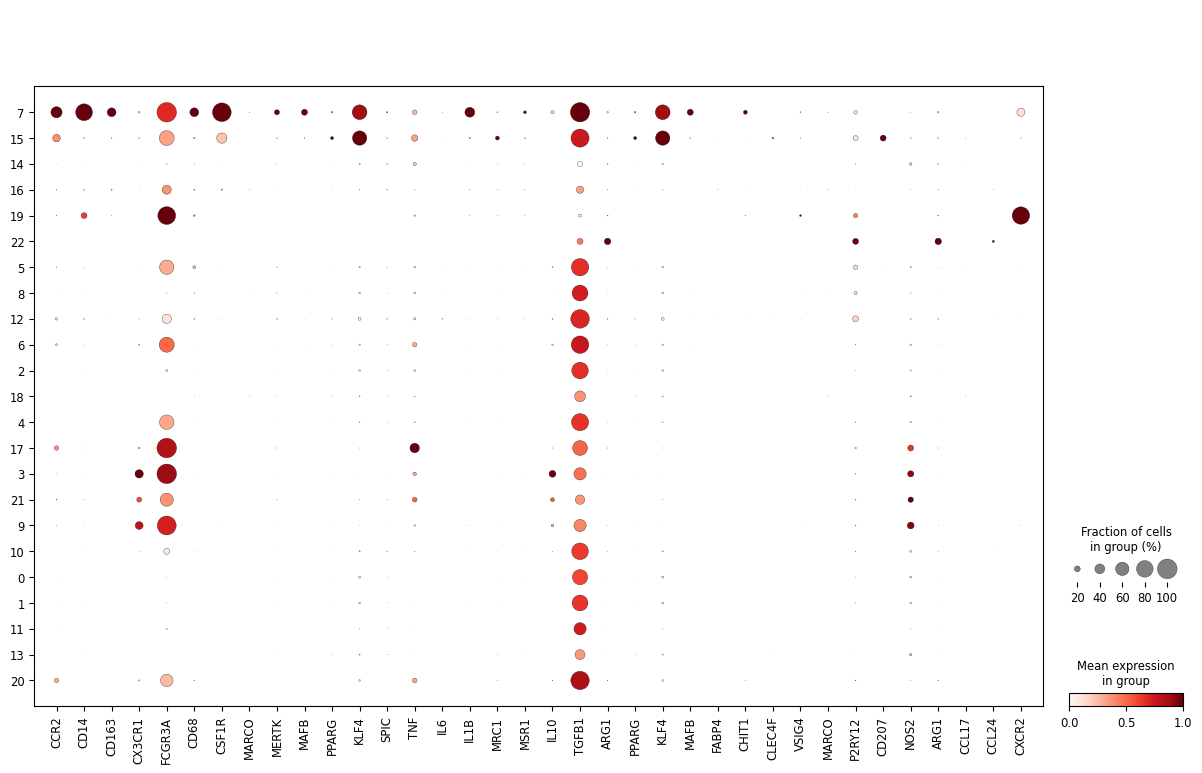

In [11]:
##macrophage specific 
sc.pl.dotplot(adata, 
              var_names=['CCR2', 'CD14', 'CD163','CX3CR1','FCGR3A','CD68','CSF1R','MARCO','MERTK','MAFB','PPARG','KLF4','SPIC','TNF','IL6','IL1B','MRC1','MSR1','IL10'
                        ,'TGFB1','ARG1','PPARG','KLF4','MAFB','FABP4','CHIT1','CLEC4F','VSIG4','MARCO','P2RY12','CD207','NOS2','ARG1','CCL17','CCL24','CXCR2'], 
              groupby='neworder', 
              standard_scale='var', 
              swap_axes=False)